In [1]:
from pathlib import Path

from ovito.io import import_file
from ovito.data import DataCollection
from ovito.modifiers import ExpressionSelectionModifier, DeleteSelectedModifier, DislocationAnalysisModifier, AssignColorModifier
from ovito.pipeline import FileSource, Pipeline
from ovito.vis import Viewport, TextLabelOverlay, ParticlesVis
from ovito.qt_compat import QtCore

from ovito.vis import OpenGLRenderer, TachyonRenderer

# FAST: For checking positions, text, and layout (Instant)
fast_renderer = OpenGLRenderer()

# SUPER DUPER GOOD: For the final report (Seconds per frame)
quality_renderer = TachyonRenderer(
    shadows=True, 
    ambient_occlusion=True, # This adds the "pro" depth/shading
    antialiasing=True
)

In [2]:
sim_dir = Path("/home/Ethan/Projects/neb_2/data/shear_S110_SV2E0_N9464_big")

frames = [0, 100, 200, 300]

output_dir_1 = sim_dir / "vis_1"
output_dir_1.mkdir(parents=True, exist_ok=True)

dump_files = sim_dir / "dump" / "dump_*.lammpstrj"

In [3]:
pipeline1 = import_file(dump_files)

# Create the modifiers
mod1 = ExpressionSelectionModifier(expression="ParticleType != 1")
mod2 = DeleteSelectedModifier()
mod3 = DislocationAnalysisModifier(input_crystal_structure=DislocationAnalysisModifier.Lattice.BCC)
mod4 = ExpressionSelectionModifier(expression="ParticleIdentifier == 58050 || ParticleIdentifier == 58051|| ParticleIdentifier == 58876")
mod5 = AssignColorModifier(color=(1.0, 0.0, 0.0))
mod6 = ExpressionSelectionModifier(expression="c_pe > -4.05")
mod7 = AssignColorModifier(color=(0.0, 1.0, 0.0))

modifiers = [mod1, mod2, mod3, mod4, mod5, mod6, mod7]

for modifier in modifiers:
    pipeline1.modifiers.append(modifier)

pipeline1.add_to_scene()

In [4]:
vis_element = pipeline1.compute().particles.vis
vis_element.scaling = 0.8

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


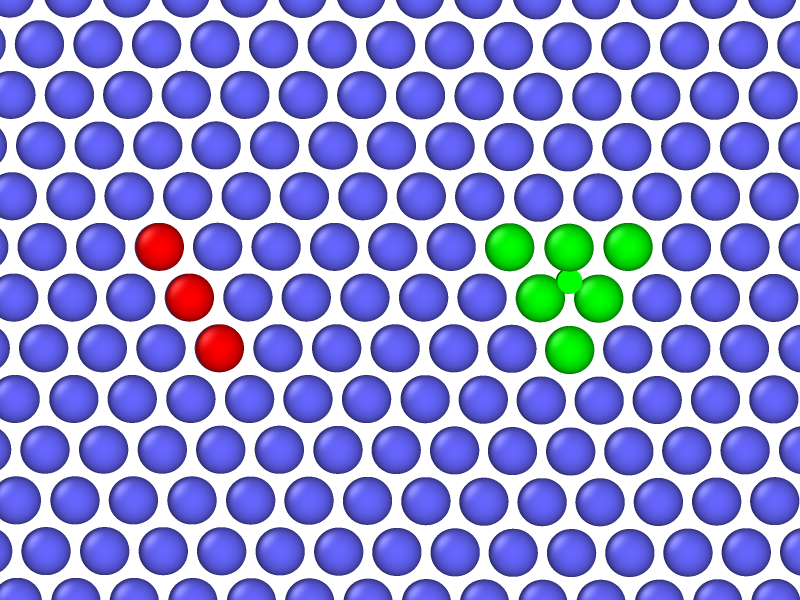

In [5]:
# Create the view port
vp1 = Viewport()
vp1.type = Viewport.Type.Ortho

"""vp1.zoom_all()

# Zoom in!
vp1.fov *= 0.08

pan_amount = vp1.fov  # Move right by 20% of the visible window
current_pos = list(vp1.camera_pos)
current_pos[0] += pan_amount 
vp1.camera_pos = tuple(current_pos)"""

# Define your target point (e.g., the center of a defect you found in the GUI)
target_point = (160, 153.0, 0.0) 

# Distance doesn't change 'zoom' in Ortho mode, but keeps the camera away from the atoms
distance = 1000.0 

# Look straight down the Z-axis
vp1.type = Viewport.Type.Ortho
vp1.camera_dir = (0, 0, -1) 
vp1.camera_pos = (target_point[0], target_point[1], target_point[2] + distance)

"""# 1. Create the overlay ONE TIME outside the loop
textOverlay = TextLabelOverlay(
    alignment = QtCore.Qt.AlignmentFlag.AlignLeft | QtCore.Qt.AlignmentFlag.AlignTop,
    offset_y = -0.025,
    offset_x = 0.025,
    font_size = 0.03,
    text_color = (0.0, 0.0, 0.0),
    background_color = (1.0, 1.0, 1.0), # White background box
    background_opacity = 0.7,           # 0.0 is invisible, 1.0 is solid white
    outline_width = 0.002
)

vp1.overlays.append(textOverlay)"""

# Now zoom is purely controlled by FOV
vp1.fov = 12 # Exactly 50 units tall

vp1.render_image(size=(800,600), background=(1,1,1), frame=245)

In [6]:
# Render the frames of interest
frames = [0, 175, 185, 200, 220, 230, 245]

for frame in frames:
    """textOverlay.text = f"Timestep: {frame*1000}"""
    
    vp1.render_image(size=(1600,1200), filename=str(output_dir_1 / f"timestep_{frame*1000}.png"), background=(1,1,1), frame=frame)

In [ ]:
# Render an animation
#vp1.render_anim(size=(1600,1200), filename=str(output_dir_1 / f"fast_anim.mp4"), background=(1,1,1), range=(175, 245), fps=7, renderer=fast_renderer)
vp1.render_anim(size=(1600,1200), filename=str(output_dir_1 / f"quality_anim.mp4"), background=(1,1,1), range=(175, 245), fps=7, renderer=quality_renderer)